# ftir_19 — the HIPS MAC fix applied across every calibration setup

## tl;dr

The deck question — apply the HIPS "MAC fix" (Fabs/6 instead of Fabs/10) to every
calibration setup — has a structural answer, shown here per-filter for all six setups in
`calibration_setup_matrix` on the fixed 190-filter cohort. Because HIPS enters every
crossplot as x = Fabs/MAC, switching MAC rescales x by a constant, so **every setup keeps
its intercept and R² exactly and its slope scales by exactly 0.6** (audited: the
recomputed fixed-cohort fits match the committed phase-2/ftir_13 metrics to 1e-9, and
intercept@MAC6 ≡ intercept@MAC10 for all six). The matrix's intercept column is therefore
MAC-proof — no MAC choice moves −4.17 / −6.91 / −3.69 / −3.22 / −1.62 — and the MAC fork
is fought entirely on **slopes**: MAC = 6 makes the raw models self-consistent
(lowest-OCEC 800 **0.95**, Ethiopia-shaped smoke **1.05**, deployed 1.14) while MAC = 10
is where the AIRSpec model lands closest (**0.86**) — the raw-at-MAC6 vs
corrected-at-MAC10 fork of ftir_13/ftir_16, now visible setup by setup as a pivot around
each fixed intercept (`output/plots/deck/mac_effect_all_calibrations.png`, slope summary
in `mac_slope_pivot.png`). One deck erratum found and fixed: the matrix quoted the
AIRSpec intercept as −1.61, but the committed value is −1.6151 → **−1.62** (ftir_13's
tl;dr had it right; `build_deck_figures.py` and the deck PNGs are corrected).

## Context & Methods

Deck follow-up to `calibration_setup_matrix` (July 2026): the matrix quotes one Addis
intercept per calibration setup, all at MAC = 10 — what happens to each setup when the
"MAC fix" is applied to the HIPS side, i.e. when HIPS EC-equivalent is computed as
Fabs/6 instead of Fabs/10?

The answer has a structural part worth stating up front. Every crossplot regresses
predicted EC (y) on HIPS EC-equivalent x = Fabs/MAC. Changing MAC rescales x by a
constant (x@MAC6 = x@MAC10 × 10/6), and an OLS fit against a constant-rescaled
regressor keeps the **same intercept and R² exactly** while the slope scales by the
inverse factor (×0.6 going from MAC 10 to MAC 6). So the MAC choice can never move any
setup's intercept — the intercept column of the matrix is MAC-proof — and the fork
between MAC = 6 and MAC = 10 is decided entirely on **slopes** (which calibration
becomes self-consistent, slope ≈ 1, under which MAC). This notebook shows that
per-filter for all six setups in the matrix, on identical axes: the calibrated data,
the fit, and both MAC conversions in each panel.

Everything is read from committed per-filter prediction tables (phase-2
`addis_calibration_predictions.csv`, ftir_11 raw lowest-OC/EC, ftir_13 AIRSpec) — no
model is fit here, so the panels cannot drift from the source notebooks. Headline
panels use the fixed phase-2 cohort (n = 190, the cohort behind every number in the
setup matrix); the metrics table also reports all available HIPS pairs (n = 239).
The spectral-analogs setup is included for completeness but flagged: it fails the
held-out TOR test and is not a candidate (ftir_10/ftir_11).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

from phase3_common import PHASE2_TABLES
from pls_transfer import regression_metrics

TABLE_DIR = Path('output/tables/ftir19')
PLOT_DIR = Path('output/plots/ftir19')
DECK_DIR = Path('output/plots/deck')
for directory in (TABLE_DIR, PLOT_DIR, DECK_DIR):
    directory.mkdir(parents=True, exist_ok=True)

INK, MUTED = '#22252A', '#6B6E75'
ACCENT, BLUE, PURPLE, GREY = '#B23327', '#2C6E9E', '#7A4FA3', '#8F8C84'

## Data

One row per Addis filter with a HIPS Fabs, one column per calibration setup, merged
from the committed prediction tables. Setups and row order mirror
`calibration_setup_matrix` exactly.

In [2]:
p2 = pd.read_csv(PHASE2_TABLES / 'pls_calibration_phase2/addis_calibration_predictions.csv')
f11 = pd.read_csv('output/tables/ftir11/addis_predictions.csv')
f13 = pd.read_csv('output/tables/ftir13/addis_predictions_corrected.csv')

data = (
    p2[['MediaId', 'ExternalFilterId', 'Fabs', 'EC_deployed_ugm3', 'EC_smoke_906_ugm3',
        'EC_smoke_shape_300_ugm3', 'EC_analog_raw_first_ugm3']]
    .merge(f11[['MediaId', 'EC_lowest_ocec_800_ugm3', 'in_fixed_phase2_cohort']],
           on='MediaId', validate='one_to_one')
    .merge(f13[['MediaId', 'lowest-OCEC 800, AIRSpec df1=6']],
           on='MediaId', validate='one_to_one')
)
assert np.allclose(data['Fabs'],
                   f11.set_index('MediaId').loc[data['MediaId'], 'Fabs'])

# (name, prediction column, colour, caveat) — matrix row order.
SETUPS = [
    ('Deployed SPARTAN', 'EC_deployed_ugm3', GREY, None),
    ('Biomass-smoke (906)', 'EC_smoke_906_ugm3', GREY, None),
    ('Ethiopia-shaped smoke (300)', 'EC_smoke_shape_300_ugm3', BLUE, None),
    ('Spectral analogs (400)', 'EC_analog_raw_first_ugm3', BLUE, 'fails held-out TOR test'),
    ('Lowest-OC/EC (800)', 'EC_lowest_ocec_800_ugm3', PURPLE, None),
    ('Lowest-OC/EC + AIRSpec', 'lowest-OCEC 800, AIRSpec df1=6', ACCENT, None),
]
fabs = data['Fabs'].to_numpy(float)
fixed_mask = data['in_fixed_phase2_cohort'].to_numpy(bool)
print(f'{len(data)} available HIPS pairs, {int(fixed_mask.sum())} in the fixed cohort')

239 available HIPS pairs, 190 in the fixed cohort


## Results

### 1. Metrics at both MACs, and the invariance audit

For every setup and both cohorts: regress predicted EC on Fabs/10 and on Fabs/6.
The audit then asserts, from the fitted numbers themselves, that (a) the fixed-cohort
MAC = 10 slopes and intercepts reproduce the committed phase-2 / ftir_13 metrics
tables exactly (1e-9), and (b) for every setup the intercept and R² are identical at
both MACs while the slope scales by exactly 0.6 — the "MAC fix" is a pure slope
rescaling everywhere. (One deck erratum falls out: the matrix's AIRSpec intercept
"−1.61" is a rounding slip for −1.6151 → −1.62.)

In [3]:
metric_rows = []
for name, column, _, caveat in SETUPS:
    prediction = data[column].to_numpy(float)
    for cohort, cohort_mask in (('fixed phase-2 cohort', fixed_mask & np.isfinite(prediction)),
                                ('available pairs', np.isfinite(prediction))):
        for mac in (10, 6):
            metric_rows.append({
                'setup': name, 'cohort': cohort, 'MAC_m2_g': mac,
                'fails_TOR_test': caveat is not None,
                **regression_metrics(fabs[cohort_mask] / mac, prediction[cohort_mask]),
            })
metrics = pd.DataFrame(metric_rows)
metrics.to_csv(TABLE_DIR / 'mac_effect_metrics.csv', index=False)
data.to_csv(TABLE_DIR / 'addis_predictions_all_setups.csv', index=False)

fixed10 = metrics.query('cohort == "fixed phase-2 cohort" and MAC_m2_g == 10').set_index('setup')
fixed6 = metrics.query('cohort == "fixed phase-2 cohort" and MAC_m2_g == 6').set_index('setup')

# Reconcile against the committed source-notebook metrics (exact, not deck rounding).
p2_metrics = pd.read_csv(PHASE2_TABLES / 'pls_calibration_phase2/addis_calibration_metrics.csv')
p2_fixed10 = p2_metrics.query('cohort == "fixed common cohort" and MAC_m2_g == 10')
f13_metrics = pd.read_csv('output/tables/ftir13/addis_metrics_corrected.csv')
f13_fixed10 = f13_metrics.query('MAC_m2_g == 10')
REFERENCE_ROWS = {
    'Deployed SPARTAN': (p2_fixed10, 'Deployed SPARTAN FTIR EC'),
    'Biomass-smoke (906)': (p2_fixed10, 'Smoke IMPROVE (906'),
    'Ethiopia-shaped smoke (300)': (p2_fixed10, 'Ethiopia-shaped smoke (300'),
    'Spectral analogs (400)': (p2_fixed10, 'Locked analog raw—first major'),
    'Lowest-OC/EC (800)': (f13_fixed10, 'lowest-OCEC 800 (raw spectra)'),
    'Lowest-OC/EC + AIRSpec': (f13_fixed10, 'lowest-OCEC 800, AIRSpec df1=6'),
}
for name, (table, key) in REFERENCE_ROWS.items():
    row = table[table['model'].str.startswith(key)].iloc[0]
    for column in ('slope', 'intercept'):
        assert abs(float(fixed10.loc[name, column]) - float(row[column])) < 1e-9, (name, column)
print('fixed-cohort MAC = 10 fits reproduce the committed phase-2 / ftir_13 metrics exactly')
print('NOTE: the deck matrix quotes the AIRSpec intercept as −1.61; the committed value is '
      f'{float(fixed10.loc["Lowest-OC/EC + AIRSpec", "intercept"]):.4f} → −1.62 at 2 dp '
      '(ftir_13 tl;dr has it right)')
for name, _, _, _ in SETUPS:
    assert abs(fixed10.loc[name, 'intercept'] - fixed6.loc[name, 'intercept']) < 1e-9, name
    assert abs(fixed10.loc[name, 'R2'] - fixed6.loc[name, 'R2']) < 1e-9, name
    assert abs(fixed6.loc[name, 'slope'] - 0.6 * fixed10.loc[name, 'slope']) < 1e-9, name
print('audit passed: matrix intercepts reproduced; intercept and R² MAC-invariant; '
      'slope@MAC6 = 0.6 × slope@MAC10 for all six setups')

display(pd.DataFrame({
    'intercept (both MACs)': fixed10['intercept'].round(2),
    'slope @ MAC 10': fixed10['slope'].round(2),
    'slope @ MAC 6': fixed6['slope'].round(2),
    'R2 (both MACs)': fixed10['R2'].round(3),
    'RMSE @ MAC 10': fixed10['RMSE'].round(2),
    'RMSE @ MAC 6': fixed6['RMSE'].round(2),
}).loc[[s[0] for s in SETUPS]])

fixed-cohort MAC = 10 fits reproduce the committed phase-2 / ftir_13 metrics exactly
NOTE: the deck matrix quotes the AIRSpec intercept as −1.61; the committed value is -1.6151 → −1.62 at 2 dp (ftir_13 tl;dr has it right)
audit passed: matrix intercepts reproduced; intercept and R² MAC-invariant; slope@MAC6 = 0.6 × slope@MAC10 for all six setups


,intercept (both MACs),slope @ MAC 10,slope @ MAC 6,R2 (both MACs),RMSE @ MAC 10,RMSE @ MAC 6
setup,,,,,,
Deployed SPARTAN,-4.17,1.90,1.14,0.764,1.49,3.25
Biomass-smoke (906),-6.91,2.65,1.59,0.685,2.85,3.01
Ethiopia-shaped smoke (300),-3.69,1.75,1.05,0.742,1.36,3.45
Spectral analogs (400),-6.43,2.91,1.75,0.755,3.96,2.23
Lowest-OC/EC (800),-3.22,1.59,0.95,0.774,1.16,3.73
Lowest-OC/EC + AIRSpec,-1.62,0.86,0.51,0.657,2.41,5.68


### 2. Every calibration with the MAC fix applied to HIPS

One panel per setup, fixed phase-2 cohort, identical axes. Filled points and the solid
fit line are the headline MAC = 10 conversion; open points and the dashed line are the
same filters with HIPS converted at MAC = 6 (the cloud stretches right by ×10/6). Both
fit lines are drawn back to x = 0: they meet at the shared intercept (black diamond) —
the MAC choice pivots each calibration around its intercept, it never moves it. For
this reason the y-axis extends below zero (the usual phase-3 clip at 0 would hide the
pivot point). The
grey dashed line is 1:1; a self-consistent calibration+MAC pairing lies along it.

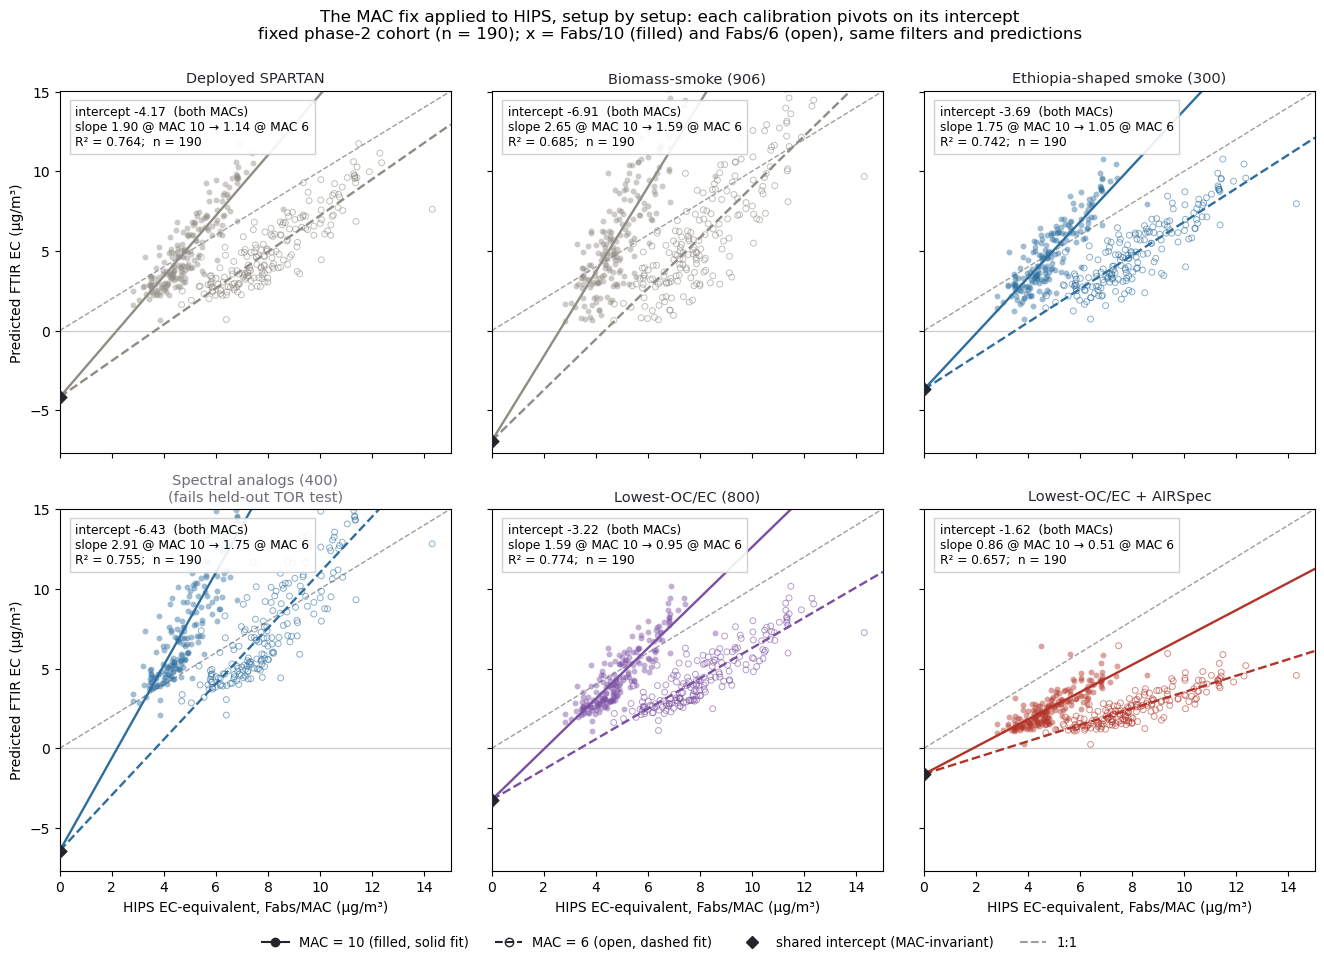

In [4]:
x10, x6 = fabs / 10, fabs / 6
hi = float(np.nanmax(x6[fixed_mask])) * 1.05
# The y-axis deliberately extends below zero (phase-3 plots normally clip at 0): the
# shared intercept is the subject of the figure, and every setup's is negative.
lo_y = float(fixed10['intercept'].min()) - 0.8

fig, axes = plt.subplots(2, 3, figsize=(13.5, 9.2), sharex=True, sharey=True)
for ax, (name, column, colour, caveat) in zip(axes.flat, SETUPS):
    prediction = data[column].to_numpy(float)
    mask = fixed_mask & np.isfinite(prediction)
    slope10, slope6 = float(fixed10.loc[name, 'slope']), float(fixed6.loc[name, 'slope'])
    intercept = float(fixed10.loc[name, 'intercept'])

    ax.plot([0, hi], [0, hi], '--', color='0.62', lw=1, zorder=1)
    ax.axhline(0, color='0.8', lw=.9, zorder=0)
    ax.scatter(x10[mask], prediction[mask], s=18, alpha=.45, color=colour, lw=0)
    ax.scatter(x6[mask], prediction[mask], s=18, alpha=.55, facecolors='none',
               edgecolors=colour, lw=.7)
    for slope, style in ((slope10, '-'), (slope6, '--')):
        ax.plot([0, hi], [intercept, slope * hi + intercept], style, color=colour, lw=1.7)
    ax.scatter([0], [intercept], marker='D', s=42, color=INK, zorder=5)

    title = name if caveat is None else f'{name}\n({caveat})'
    ax.set_title(title, fontsize=10.5,
                 color=INK if caveat is None else MUTED)
    ax.text(.04, .96,
            f'intercept {intercept:+.2f}  (both MACs)\n'
            f'slope {slope10:.2f} @ MAC 10 → {slope6:.2f} @ MAC 6\n'
            f'R² = {fixed10.loc[name, "R2"]:.3f};  n = {int(fixed10.loc[name, "n"])}',
            transform=ax.transAxes, va='top', fontsize=8.8,
            bbox=dict(facecolor='white', edgecolor='0.8', alpha=.9))
    ax.set_xlim(0, hi)
    ax.set_ylim(lo_y, hi)
for ax in axes[1]:
    ax.set_xlabel('HIPS EC-equivalent, Fabs/MAC (µg/m³)')
for ax in axes[:, 0]:
    ax.set_ylabel('Predicted FTIR EC (µg/m³)')
fig.legend(handles=[
    Line2D([], [], marker='o', ls='-', color=INK, markersize=6,
           label='MAC = 10 (filled, solid fit)'),
    Line2D([], [], marker='o', ls='--', color=INK, markersize=6, markerfacecolor='none',
           label='MAC = 6 (open, dashed fit)'),
    Line2D([], [], marker='D', ls='', color=INK, markersize=6,
           label='shared intercept (MAC-invariant)'),
    Line2D([], [], ls='--', color='0.62', label='1:1'),
], loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(.5, -.035), fontsize=9.5)
fig.suptitle('The MAC fix applied to HIPS, setup by setup: each calibration pivots on '
             'its intercept\nfixed phase-2 cohort (n = 190); x = Fabs/10 (filled) and '
             'Fabs/6 (open), same filters and predictions', y=1.0)
fig.tight_layout()
for target in (PLOT_DIR / 'mac_effect_all_calibrations.png',
               DECK_DIR / 'mac_effect_all_calibrations.png'):
    fig.savefig(target, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

### 3. The decision view: slopes swing with MAC, intercepts stand still

Dumbbells: each setup's Addis slope at MAC = 10 (filled dot, value to its right) and
MAC = 6 (open dot, value to its left), with the MAC-invariant intercept in its own
column on the right. Both slope numbers are printed at their markers, and values within
0.1 of self-consistency are bold. Self-consistency (slope = 1) is the vertical line and
shaded band — which setups reach it, and under which MAC, is the entire content of the
MAC fork.

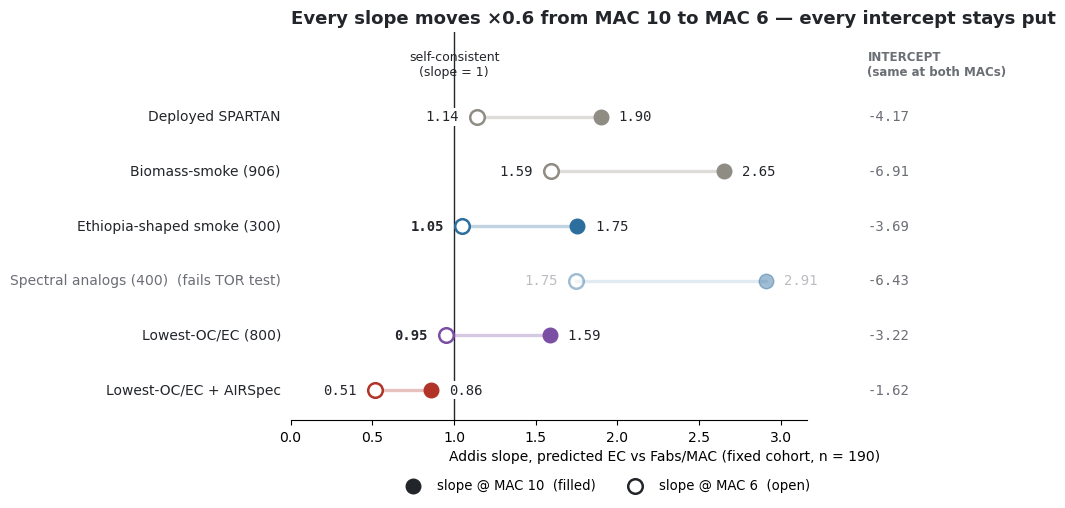

In [5]:
order = [s[0] for s in SETUPS][::-1]
slope_max = float(fixed10['slope'].max())
intercept_x = slope_max + .62          # fixed column so intercepts read as a column
x_right = intercept_x + 1.05

fig, ax = plt.subplots(figsize=(10.6, 5.2))
for yi, name in enumerate(order):
    colour = next(c for n, _, c, _ in SETUPS if n == name)
    caveat = next(cv for n, _, _, cv in SETUPS if n == name)
    slope10, slope6 = float(fixed10.loc[name, 'slope']), float(fixed6.loc[name, 'slope'])
    alpha = .45 if caveat else 1.0
    ax.plot([slope6, slope10], [yi, yi], color=colour, lw=2.4, alpha=.3 * alpha, zorder=2)
    ax.scatter([slope10], [yi], s=110, color=colour, alpha=alpha, zorder=3)
    ax.scatter([slope6], [yi], s=110, facecolors='white', edgecolors=colour,
               lw=1.8, alpha=alpha, zorder=3)
    label = name + ('  (fails TOR test)' if caveat else '')
    ax.text(-.06, yi, label, ha='right', va='center', fontsize=10,
            color=MUTED if caveat else INK)
    # Both slope values printed at their own marker: MAC 6 left of the open dot,
    # MAC 10 right of the filled dot. Self-consistent values (|slope − 1| ≤ 0.1) bold.
    for slope, side in ((slope6, 'right'), (slope10, 'left')):
        offset = -.11 if side == 'right' else .11
        near_one = abs(slope - 1) <= .1 and not caveat
        # White bbox so the slope = 1 rule never runs through a digit.
        ax.text(slope + offset, yi, f'{slope:.2f}', ha=side, va='center', fontsize=10,
                color=INK if not caveat else MUTED, alpha=alpha, zorder=4,
                fontweight='bold' if near_one else 'normal', fontfamily='monospace',
                bbox=dict(facecolor='white', edgecolor='none', pad=1.4))
    ax.text(intercept_x, yi, f'{fixed10.loc[name, "intercept"]:+.2f}', va='center',
            ha='left', fontsize=10, color=MUTED, fontfamily='monospace')
ax.axvline(1, color=INK, lw=1, zorder=1)

top = len(order) - .3
ax.text(1, top, 'self-consistent\n(slope = 1)', fontsize=9, color=INK, ha='center',
        va='bottom')
ax.text(intercept_x, top, 'INTERCEPT\n(same at both MACs)', fontsize=8.5, color=MUTED,
        ha='left', va='bottom', fontweight='bold')
ax.scatter([], [], s=110, color=INK, label='slope @ MAC 10  (filled)')
ax.scatter([], [], s=110, facecolors='white', edgecolors=INK, lw=1.8,
           label='slope @ MAC 6  (open)')
ax.legend(loc='upper center', frameon=False, fontsize=9.5, ncol=2,
          bbox_to_anchor=(.42, -.12))
ax.set_yticks([])
ax.set_ylim(-.55, len(order) + .55)
ax.set_xlim(0, x_right)
ax.set_xticks(np.arange(0, slope_max + .5, .5))
ax.set_xlabel('Addis slope, predicted EC vs Fabs/MAC (fixed cohort, n = 190)')
ax.set_title('Every slope moves ×0.6 from MAC 10 to MAC 6 — every intercept stays put',
             fontsize=13, fontweight='bold', color=INK, loc='left')
for spine in ('top', 'right', 'left'):
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_bounds(0, slope_max + .25)
fig.tight_layout()
for target in (PLOT_DIR / 'mac_slope_pivot.png', DECK_DIR / 'mac_slope_pivot.png'):
    fig.savefig(target, dpi=190, bbox_inches='tight', facecolor='white')
plt.show()

## Takeaways

- **The MAC fix cannot repair any intercept.** Changing the assumed HIPS MAC rescales the
  x-axis only, so each calibration pivots around its intercept — the offsets in the setup
  matrix survive any MAC choice, and arguments about the intercept and arguments about
  MAC are fully separable.
- **The MAC fork is a slope contest, and the sides are unchanged**: raw-spectra models
  look self-consistent at MAC = 6 (OCEC-800 0.95, Ethiopia-shaped 1.05, deployed 1.14),
  the AIRSpec OCEC-800 model at MAC = 10 (0.86). External evidence (ftir_16's IMPROVE
  implied-MAC bridge, median 10.05 at Addis-like OC/EC; ftir_15's season-stable corrected
  residuals) still tilts the fork toward MAC ≈ 10 + the corrected model.
- **R² is MAC-invariant too, so "fit quality" cannot arbitrate MAC** — RMSE and bias do
  swing with MAC, but only as re-expressions of the slope change, not as independent
  evidence.
- **Deck correction**: AIRSpec intercept is −1.62 (−1.6151), not −1.61;
  `calibration_setup_matrix.png` and `intercept_ladder.png` regenerated.
- **Caveats**: headline panels are the fixed 190-filter cohort (available-pairs rows in
  the metrics CSV); the spectral-analogs setup is shown only for completeness (fails the
  held-out TOR test); and IMPROVE-vs-SPARTAN HIPS protocol comparability remains an
  assumption, as in ftir_08/ftir_16/ftir_18.